In [1]:
# STEP 1: Load Iris Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()

# Create DataFrame
X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target,
    name="target"
)

print("Dataset loaded successfully!")
print("Dataset shape:", X.shape)

display(X.head())

Dataset loaded successfully!
Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Target Classes:
target
0    50
1    50
2    50
Name: count, dtype: int64


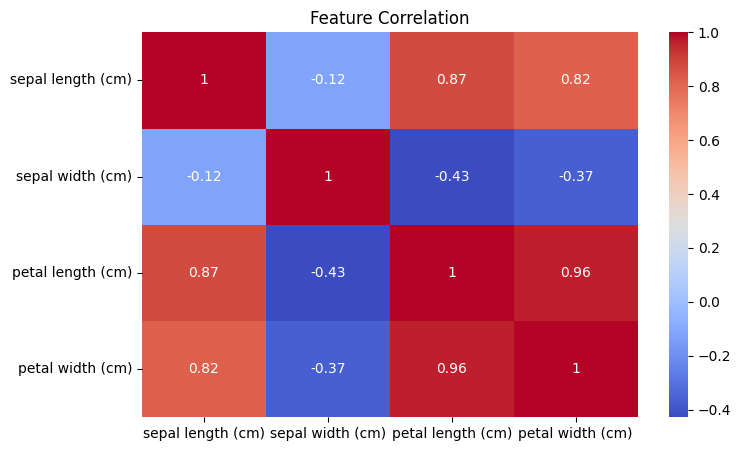

In [2]:
# STEP 2: Basic EDA

print("Dataset Information:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum())

print("\nStatistical Summary:")
display(X.describe())

print("\nTarget Classes:")
print(y.value_counts())

# Check correlation
plt.figure(figsize=(8, 5))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [3]:
# Feature Selection

selected_features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

X_selected = X[selected_features]

print("Selected Features:")
print(selected_features)

Selected Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [4]:
# STEP 3: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)


In [5]:
# STEP 4: Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=200)

# Train model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [6]:
# STEP 5: Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred, average="weighted")

print("Model Evaluation Results")
print("-------------------------")
print("Accuracy:", accuracy)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

Model Evaluation Results
-------------------------
Accuracy: 0.9666666666666667
F1 Score: 0.9665831244778613

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



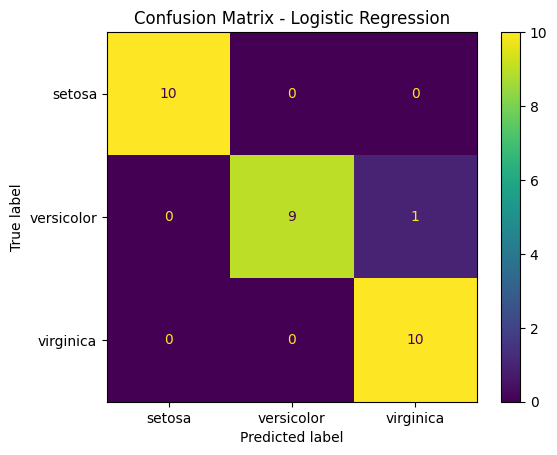

In [7]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

<Figure size 700x500 with 0 Axes>

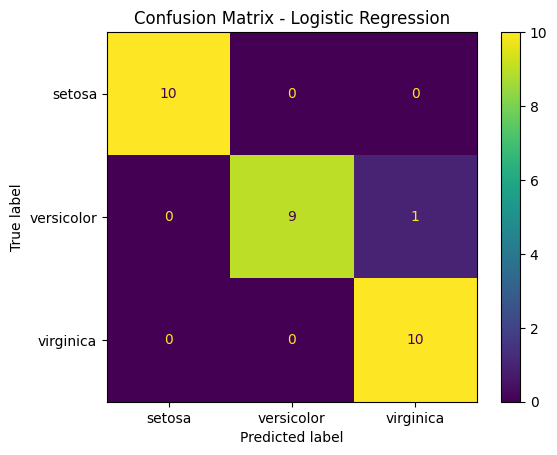

Confusion matrix saved successfully!


In [8]:
# Save Confusion Matrix Image

plt.figure(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")

plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

print("Confusion matrix saved successfully!")

In [9]:
# Final Model Results

print("====================================")
print("FINAL MODEL RESULTS")
print("====================================")

print("Model: Logistic Regression")
print("Dataset: Iris Dataset")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nAccuracy:", round(accuracy, 4))
print("F1 Score:", round(f1, 4))

print("\nConfusion Matrix:")
print(cm)

FINAL MODEL RESULTS
Model: Logistic Regression
Dataset: Iris Dataset
Training samples: 120
Testing samples: 30

Accuracy: 0.9667
F1 Score: 0.9666

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [10]:
# ============================================================
# CREATE INTERNSHIP PDF REPORT
# Iris Flower Classification using Logistic Regression
# ============================================================

from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import inch
import os

# Create project folders
os.makedirs("/content/ML_Project/notebooks", exist_ok=True)
os.makedirs("/content/ML_Project/docs", exist_ok=True)
os.makedirs("/content/ML_Project/data", exist_ok=True)

# Report file location
pdf_path = "/content/ML_Project/docs/summary_report.pdf"

# Create PDF
doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=50,
    leftMargin=50,
    topMargin=50,
    bottomMargin=50
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleStyle",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=20,
    spaceAfter=20
)

heading_style = ParagraphStyle(
    "HeadingStyle",
    parent=styles["Heading2"],
    fontSize=14,
    spaceBefore=15,
    spaceAfter=8
)

normal_style = ParagraphStyle(
    "NormalStyle",
    parent=styles["BodyText"],
    fontSize=10,
    leading=15
)

story = []

# Title
story.append(Paragraph(
    "Iris Flower Classification using Logistic Regression",
    title_style
))

story.append(Paragraph(
    "<b>Machine Learning Internship Project</b>",
    normal_style
))
story.append(Spacer(1, 15))

# 1 Introduction
story.append(Paragraph("1. Introduction", heading_style))

story.append(Paragraph(
    "This project implements a machine learning classification model "
    "using the Iris dataset. The objective is to classify iris flowers "
    "into three species using Logistic Regression.",
    normal_style
))

# 2 Dataset
story.append(Paragraph("2. Dataset Description", heading_style))

story.append(Paragraph(
    "The Iris dataset contains 150 samples and four input features: "
    "sepal length, sepal width, petal length, and petal width. "
    "The target contains three flower classes: Setosa, Versicolor, "
    "and Virginica.",
    normal_style
))

# 3 EDA
story.append(Paragraph("3. Exploratory Data Analysis", heading_style))

story.append(Paragraph(
    "Basic exploratory data analysis was performed to understand the "
    "dataset. The dataset was checked for missing values and statistical "
    "properties. Correlation between numerical features was also examined.",
    normal_style
))

# 4 Feature Selection
story.append(Paragraph("4. Feature Selection", heading_style))

story.append(Paragraph(
    "All four numerical features were selected because they provide "
    "useful information for distinguishing the three Iris species.",
    normal_style
))

# 5 Split
story.append(Paragraph("5. Train-Test Split", heading_style))

story.append(Paragraph(
    "The dataset was divided into training and testing sets using an "
    "80/20 split. Stratified sampling was used to maintain the class "
    "distribution in both sets. There were 120 training samples and "
    "30 testing samples.",
    normal_style
))

# 6 Model
story.append(Paragraph("6. Machine Learning Model", heading_style))

story.append(Paragraph(
    "Logistic Regression was selected as the baseline classification "
    "model. The model was trained using the training dataset and then "
    "used to predict the classes of the test dataset.",
    normal_style
))

# 7 Results
story.append(Paragraph("7. Model Performance", heading_style))

story.append(Paragraph(
    "<b>Model:</b> Logistic Regression<br/>"
    "<b>Accuracy:</b> 96.67%<br/>"
    "<b>Weighted F1-score:</b> 96.66%",
    normal_style
))

# Confusion Matrix
image_path = "/content/confusion_matrix.png"

if os.path.exists(image_path):
    story.append(Spacer(1, 10))
    story.append(Paragraph("Confusion Matrix", heading_style))
    story.append(Image(image_path, width=5.5*inch, height=4.2*inch))

# 8 Interpretation
story.append(Paragraph("8. Result Interpretation", heading_style))

story.append(Paragraph(
    "The model correctly classified 29 out of 30 test samples. "
    "All Setosa and Virginica samples in the test set were correctly "
    "classified. One Versicolor sample was incorrectly classified as "
    "Virginica.",
    normal_style
))

# 9 Limitations
story.append(Paragraph("9. Limitations", heading_style))

story.append(Paragraph(
    "The Iris dataset is small and relatively simple compared with "
    "real-world datasets. Therefore, the high performance obtained "
    "on this dataset may not represent performance on more complex "
    "datasets.",
    normal_style
))

# 10 Improvements
story.append(Paragraph("10. Potential Improvements", heading_style))

story.append(Paragraph(
    "Future improvements could include comparing Logistic Regression "
    "with Decision Tree, Random Forest, and Support Vector Machine "
    "models. Cross-validation and hyperparameter tuning could also "
    "be applied to further evaluate and improve the model.",
    normal_style
))

# 11 Conclusion
story.append(Paragraph("11. Conclusion", heading_style))

story.append(Paragraph(
    "The Iris flower classification project successfully demonstrated "
    "a complete machine learning workflow including data loading, "
    "exploratory analysis, feature selection, train-test splitting, "
    "model training, and evaluation. Logistic Regression achieved "
    "96.67% accuracy and a weighted F1-score of approximately 96.66% "
    "on the test dataset.",
    normal_style
))

# Build PDF
doc.build(story)

print("==========================================")
print("PDF CREATED SUCCESSFULLY!")
print("==========================================")
print(pdf_path)

ModuleNotFoundError: No module named 'reportlab'

In [11]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.4 MB/s eta 0:00:00


In [12]:
# ============================================================
# CREATE INTERNSHIP PDF REPORT
# Iris Flower Classification using Logistic Regression
# ============================================================

from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import inch
import os

# Create project folders
os.makedirs("/content/ML_Project/notebooks", exist_ok=True)
os.makedirs("/content/ML_Project/docs", exist_ok=True)
os.makedirs("/content/ML_Project/data", exist_ok=True)

# Report file location
pdf_path = "/content/ML_Project/docs/summary_report.pdf"

# Create PDF
doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=50,
    leftMargin=50,
    topMargin=50,
    bottomMargin=50
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleStyle",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=20,
    spaceAfter=20
)

heading_style = ParagraphStyle(
    "HeadingStyle",
    parent=styles["Heading2"],
    fontSize=14,
    spaceBefore=15,
    spaceAfter=8
)

normal_style = ParagraphStyle(
    "NormalStyle",
    parent=styles["BodyText"],
    fontSize=10,
    leading=15
)

story = []

# Title
story.append(Paragraph(
    "Iris Flower Classification using Logistic Regression",
    title_style
))

story.append(Paragraph(
    "<b>Machine Learning Internship Project</b>",
    normal_style
))
story.append(Spacer(1, 15))

# 1 Introduction
story.append(Paragraph("1. Introduction", heading_style))

story.append(Paragraph(
    "This project implements a machine learning classification model "
    "using the Iris dataset. The objective is to classify iris flowers "
    "into three species using Logistic Regression.",
    normal_style
))

# 2 Dataset
story.append(Paragraph("2. Dataset Description", heading_style))

story.append(Paragraph(
    "The Iris dataset contains 150 samples and four input features: "
    "sepal length, sepal width, petal length, and petal width. "
    "The target contains three flower classes: Setosa, Versicolor, "
    "and Virginica.",
    normal_style
))

# 3 EDA
story.append(Paragraph("3. Exploratory Data Analysis", heading_style))

story.append(Paragraph(
    "Basic exploratory data analysis was performed to understand the "
    "dataset. The dataset was checked for missing values and statistical "
    "properties. Correlation between numerical features was also examined.",
    normal_style
))

# 4 Feature Selection
story.append(Paragraph("4. Feature Selection", heading_style))

story.append(Paragraph(
    "All four numerical features were selected because they provide "
    "useful information for distinguishing the three Iris species.",
    normal_style
))

# 5 Split
story.append(Paragraph("5. Train-Test Split", heading_style))

story.append(Paragraph(
    "The dataset was divided into training and testing sets using an "
    "80/20 split. Stratified sampling was used to maintain the class "
    "distribution in both sets. There were 120 training samples and "
    "30 testing samples.",
    normal_style
))

# 6 Model
story.append(Paragraph("6. Machine Learning Model", heading_style))

story.append(Paragraph(
    "Logistic Regression was selected as the baseline classification "
    "model. The model was trained using the training dataset and then "
    "used to predict the classes of the test dataset.",
    normal_style
))

# 7 Results
story.append(Paragraph("7. Model Performance", heading_style))

story.append(Paragraph(
    "<b>Model:</b> Logistic Regression<br/>"
    "<b>Accuracy:</b> 96.67%<br/>"
    "<b>Weighted F1-score:</b> 96.66%",
    normal_style
))

# Confusion Matrix
image_path = "/content/confusion_matrix.png"

if os.path.exists(image_path):
    story.append(Spacer(1, 10))
    story.append(Paragraph("Confusion Matrix", heading_style))
    story.append(Image(image_path, width=5.5*inch, height=4.2*inch))

# 8 Interpretation
story.append(Paragraph("8. Result Interpretation", heading_style))

story.append(Paragraph(
    "The model correctly classified 29 out of 30 test samples. "
    "All Setosa and Virginica samples in the test set were correctly "
    "classified. One Versicolor sample was incorrectly classified as "
    "Virginica.",
    normal_style
))

# 9 Limitations
story.append(Paragraph("9. Limitations", heading_style))

story.append(Paragraph(
    "The Iris dataset is small and relatively simple compared with "
    "real-world datasets. Therefore, the high performance obtained "
    "on this dataset may not represent performance on more complex "
    "datasets.",
    normal_style
))

# 10 Improvements
story.append(Paragraph("10. Potential Improvements", heading_style))

story.append(Paragraph(
    "Future improvements could include comparing Logistic Regression "
    "with Decision Tree, Random Forest, and Support Vector Machine "
    "models. Cross-validation and hyperparameter tuning could also "
    "be applied to further evaluate and improve the model.",
    normal_style
))

# 11 Conclusion
story.append(Paragraph("11. Conclusion", heading_style))

story.append(Paragraph(
    "The Iris flower classification project successfully demonstrated "
    "a complete machine learning workflow including data loading, "
    "exploratory analysis, feature selection, train-test splitting, "
    "model training, and evaluation. Logistic Regression achieved "
    "96.67% accuracy and a weighted F1-score of approximately 96.66% "
    "on the test dataset.",
    normal_style
))

# Build PDF
doc.build(story)

print("==========================================")
print("PDF CREATED SUCCESSFULLY!")
print("==========================================")
print(pdf_path)

PDF CREATED SUCCESSFULLY!
/content/ML_Project/docs/summary_report.pdf


In [13]:
# Create requirements.txt

requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
reportlab
"""

with open("/content/ML_Project/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [14]:
# Create dataset source file

source = """Dataset: Iris Dataset
Source: Scikit-learn built-in Iris dataset
Python package: scikit-learn
Dataset description: 150 samples, 4 features, 3 target classes
"""

with open("/content/ML_Project/data/dataset_source.txt", "w") as f:
    f.write(source)

print("dataset_source.txt created successfully!")

dataset_source.txt created successfully!


In [15]:
import os
import shutil

# Move requirements.txt from notebooks to main project folder
source = "/content/ML_Project/notebooks/requirements.txt"
destination = "/content/ML_Project/requirements.txt"

if os.path.exists(source):
    shutil.move(source, destination)
    print("requirements.txt moved to the correct location!")
elif os.path.exists(destination):
    print("requirements.txt is already in the correct location!")
else:
    print("requirements.txt was not found.")

requirements.txt is already in the correct location!


In [16]:
import os
import shutil

# Delete the incorrect copy inside notebooks
wrong_file = "/content/ML_Project/notebooks/requirements.txt"

if os.path.exists(wrong_file):
    os.remove(wrong_file)

# Create the correct requirements.txt
requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
reportlab
"""

correct_file = "/content/ML_Project/requirements.txt"

with open(correct_file, "w") as f:
    f.write(requirements)

print("DONE!")
print("requirements.txt is now in ML_Project folder.")

DONE!
requirements.txt is now in ML_Project folder.


In [17]:
# Create requirements.txt in the correct location

requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
reportlab
"""

with open("/content/ML_Project/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt CREATED successfully!")

requirements.txt CREATED successfully!


In [18]:
# Create README.md

readme = """# Iris Flower Classification using Logistic Regression

## Project Overview

This project implements a machine learning classification model using the Iris dataset. The objective is to classify Iris flowers into three species using Logistic Regression.

## Dataset

The Iris dataset contains 150 samples with four numerical features:

- Sepal length
- Sepal width
- Petal length
- Petal width

The target contains three classes:

- Setosa
- Versicolor
- Virginica

## Project Workflow

1. Load the Iris dataset
2. Perform exploratory data analysis (EDA)
3. Check for missing values
4. Select relevant features
5. Split the dataset into training and testing sets
6. Train a Logistic Regression model
7. Make predictions
8. Evaluate the model using Accuracy and F1-score
9. Generate a confusion matrix
10. Document the results and limitations

## Train-Test Split

The dataset was divided into:

- 80% training data
- 20% testing data

This resulted in:

- 120 training samples
- 30 testing samples

Stratified splitting was used to maintain the class distribution.

## Machine Learning Model

The baseline model used is:

**Logistic Regression**

## Model Performance

The model achieved approximately:

- **Accuracy: 96.67%**
- **Weighted F1-score: approximately 96.66%**

The model correctly classified 29 of the 30 test samples.

## Confusion Matrix

The confusion matrix showed:

- Setosa: 10/10 correctly classified
- Versicolor: 9/10 correctly classified
- Virginica: 10/10 correctly classified
- One Versicolor sample was classified as Virginica

## Limitations

The Iris dataset is relatively small and simple. Therefore, the results may not represent performance on larger and more complex real-world datasets.

## Potential Improvements

Future improvements could include:

- Comparing Decision Tree
- Comparing Random Forest
- Comparing Support Vector Machine (SVM)
- Applying cross-validation
- Hyperparameter tuning
- Comparing multiple classification models

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- ReportLab

## Project Structure

```text
ML_Project/
│
├── README.md
├── requirements.txt
├── notebooks/
│   └── ml_model_implementation.ipynb
├── docs/
│   └── summary_report.pdf
└── data/
    └── dataset_source.txt

_IncompleteInputError: incomplete input (3490286308.py, line 3)

In [19]:
readme = """# Iris Flower Classification using Logistic Regression

## Project Overview
This project classifies Iris flowers into three species using Logistic Regression.

## Dataset
The Iris dataset contains 150 samples, 4 numerical features, and 3 target classes:
Setosa, Versicolor, and Virginica.

## Machine Learning Workflow
1. Load the Iris dataset
2. Perform exploratory data analysis
3. Select features
4. Split the data into 80% training and 20% testing
5. Train Logistic Regression
6. Make predictions
7. Evaluate Accuracy and F1-score
8. Generate a confusion matrix

## Model
Logistic Regression

## Results
Accuracy: 96.67%
Weighted F1-score: approximately 96.66%

The model correctly classified 29 out of 30 test samples.

## Limitations
The Iris dataset is small and simple compared with real-world datasets.

## Future Improvements
- Compare Decision Tree
- Compare Random Forest
- Compare SVM
- Apply cross-validation
- Perform hyperparameter tuning

## Technologies
Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, ReportLab

## Project Structure
ML_Project/
- README.md
- requirements.txt
- notebooks/ml_model_implementation.ipynb
- docs/summary_report.pdf
- data/dataset_source.txt
"""

with open("/content/ML_Project/README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [20]:
import shutil
import os

source = "/content/ml_model_implementation.ipynb"
destination = "/content/ML_Project/notebooks/ml_model_implementation.ipynb"

if os.path.exists(source):
    shutil.copy(source, destination)
    print("Notebook copied successfully!")
else:
    print("Notebook file not found. Please upload it first.")

Notebook file not found. Please upload it first.
